# 페니실린 생산 공정 골든배치 기반 이탈진단 — 정리노트북

팀 프로젝트: IndPenSim 데이터셋 기반 골든배치(정상 운전 기준선) 구축 → SMAPE 이탈점수 계산 → 전략별(RC/OC/APC) 임계값 초과 시 경보 → ML팀 인계용 관리한계 자료 저장까지, 6개월 가까이 탐색한 내용 중 **최종 확정된 파이프라인만** 정리한 노트북입니다.

(실행 환경에 `data/processed/merged_data.csv`가 있어야 실제로 동작합니다. 위에서부터 순서대로 실행하면 됩니다.)

## 1. 데이터 로드 및 전처리

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import platform
import matplotlib.pyplot as plt

# 한글 폰트 설정 (그래프에 한글이 깨져 나오는 문제 해결)
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
elif system_name == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:                                 # Linux 등 — 나눔고딕 설치 필요할 수 있음
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지


In [3]:
df = pd.read_csv('data/processed/merged_data.csv', encoding='utf-8')  # 팀원 누구나 저장소 루트에서 실행하면 되도록 상대경로로 수정
df.shape

(113935, 39)

In [4]:
column_map = {
    # --- 1. 공정 상태 & 핵심 품질 변수 ---
    'Penicillin concentration(P:g/L)': '페니실린농도(g/L)',
    'Substrate concentration(S:g/L)': '기질농도(g/L)',
    'Dissolved oxygen concentration(DO2:mg/L)': '용존산소농도(mg/L)',
    'Vessel Volume(V:L)': '발효조부피(L)',
    'pH(pH:pH)': '수소이온농도(pH)',
    'Temperature(T:K)': '발효온도(K)',

    # --- 2. 실시간 공정 제어 및 상태 센서 변수 ---
    'Agitator RPM(RPM:RPM)': '교반기회전수(RPM)',
    'Sugar feed rate(Fs:L/h)': '당공급유량(L/h)',
    'Aeration rate(Fg:L/h)': '공기주입유량(L/h)',
    'Acid flow rate(Fa:L/h)': '산투입유량(L/h)',
    'Base flow rate(Fb:L/h)': '염기투입유량(L/h)',
    'Heating/cooling water flow rate(Fc:L/h)': '냉난방수유량(L/h)',
    'Heating water flow rate(Fh:L/h)': '가열전용유량(L/h)',
    'Water for injection/dilution(Fw:L/h)': '희석수투입유량(L/h)',
    'PAA flow(Fpaa:PAA flow (L/h))': 'PAA투입유량(L/h)',
    'Oil flow(Foil:L/hr)': '오일투입유량(L/h)',
    'Air head pressure(pressure:bar)': '상부기압(bar)',
    'Generated heat(Q:kJ)': '발생열량(kJ)',
    'Vessel Weight(Wt:Kg)': '발효조중량(kg)',
    'Dumped broth flow(Fremoved:L/h)': '배양액제거유량(L/h)',
    'Ammonia shots(NH3_shots:kgs)': '암모니아투입량(kg)',
    'carbon dioxide percent in off-gas(CO2outgas:%)': '배가스_CO2비율(%)',
    'Oxygen in percent in off-gas(O2:O2  (%))': '배가스_O2비율(%)',
    'Oxygen Uptake Rate(OUR:(g min^{-1}))': '산소소모율(g/min)',
    'Carbon evolution rate(CER:g/h)': '이산화탄소배출율(g/h)',

    # --- 3. 식별자, 제어 플래그 & 결함(Fault) 변수 ---
    'Batch_ID': '배치번호',
    'Batch ref': '배치번호_참조',
    'Time (h)': '발효시간(h)',
    'Fault ref(0-NoFault 1-Fault)': '결함여부_배치단위',
    'Fault reference(Fault_ref:Fault ref)': '결함여부_구간단위',
    '0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref)': '제어원인플래그(0_Recipe_1_Operator)',

    # --- 4. 오프라인 측정 변수 (결측 98%+, X값 금지) ---
    'Offline Biomass concentratio(X_offline:X(g L^{-1}))': '바이오매스농도_오프라인(g/L)',
    'Offline Penicillin concentration(P_offline:P(g L^{-1}))': '페니실린농도_오프라인(g/L)',
    'PAA concentration offline(PAA_offline:PAA (g L^{-1}))': 'PAA농도_오프라인(g/L)',
    'NH_3 concentration off-line(NH3_offline:NH3 (g L^{-1}))': '암모니아농도_오프라인(g/L)',
    'Viscosity(Viscosity_offline:centPoise)': '점도_오프라인(cP)',

    # --- 5. 원본 수율 & 수확량 타겟 변수 ---
    'Penicllin_yield_total (kg)': '총수율(kg)',
    'Penicllin_harvested_end_of_batch (kg)': '종료시수확량(kg)',
    'Penicllin_harvested_during_batch(kg)': '중간수확량(kg)',
}

df = df.rename(columns=column_map)


def batch_to_strategy(batch_id):
    if 1 <= batch_id <= 30:
        return 'RC'
    elif 31 <= batch_id <= 60:
        return 'OC'
    elif 61 <= batch_id <= 90:
        return 'APC'
    else:
        return 'Fault'


df['제어전략그룹'] = df['배치번호'].apply(batch_to_strategy)
df.columns

Index(['발효시간(h)', '공기주입유량(L/h)', '교반기회전수(RPM)', '당공급유량(L/h)', '산투입유량(L/h)',
       '염기투입유량(L/h)', '냉난방수유량(L/h)', '가열전용유량(L/h)', '희석수투입유량(L/h)',
       '상부기압(bar)', '배양액제거유량(L/h)', '기질농도(g/L)', '용존산소농도(mg/L)', '페니실린농도(g/L)',
       '발효조부피(L)', '발효조중량(kg)', '수소이온농도(pH)', '발효온도(K)', '발생열량(kJ)',
       '배가스_CO2비율(%)', 'PAA투입유량(L/h)', 'PAA농도_오프라인(g/L)', '오일투입유량(L/h)',
       '암모니아농도_오프라인(g/L)', '산소소모율(g/min)', '배가스_O2비율(%)', '페니실린농도_오프라인(g/L)',
       '바이오매스농도_오프라인(g/L)', '이산화탄소배출율(g/h)', '암모니아투입량(kg)', '점도_오프라인(cP)',
       '결함여부_구간단위', '제어원인플래그(0_Recipe_1_Operator)', '배치번호', '배치번호_참조',
       '중간수확량(kg)', '종료시수확량(kg)', '총수율(kg)', '결함여부_배치단위', '제어전략그룹'],
      dtype='object')

In [5]:
df['공정진행률'] = df.groupby('배치번호')['발효시간(h)'].transform(lambda t: t / t.max())
df[['배치번호', '발효시간(h)', '공정진행률']].head()

,배치번호,발효시간(h),공정진행률
0,1,0.2,0.000885
1,1,0.4,0.001770
2,1,0.6,0.002655
3,1,0.8,0.003540
4,1,1.0,0.004425


In [6]:
print("배치 수:", df['배치번호'].nunique())
print("전체 shape:", df.shape)

time_diff = df.groupby('배치번호')['발효시간(h)'].diff()
print("측정 시간간격(상위):", time_diff.round(4).value_counts().head(3).to_dict())

batch_duration = df.groupby('배치번호')['발효시간(h)'].max()
print("배치 길이(h): 최소 {:.0f}, 최대 {:.0f}, 평균 {:.1f}, 표준편차 {:.1f}".format(
    batch_duration.min(), batch_duration.max(), batch_duration.mean(), batch_duration.std()))

first_fault_progress = df[df['결함여부_구간단위'] == 1].groupby('배치번호')['공정진행률'].min()
print("Fault 최초발생 공정진행률: 평균 {:.1%}, 중앙값 {:.1%}, 최댓값 {:.1%}".format(
    first_fault_progress.mean(), first_fault_progress.median(), first_fault_progress.max()))

배치 수: 100
전체 shape: (113935, 41)
측정 시간간격(상위): {0.2: 113835}
배치 길이(h): 최소 167, 최대 290, 평균 227.9, 표준편차 18.2
Fault 최초발생 공정진행률: 평균 18.5%, 중앙값 9.2%, 최댓값 34.8%


### 데이터 개요 요약
- 발효시간 간격은 전 배치 공통 12분(0.2h) 고정
- 배치 길이가 배치마다 다름(최소 167h ~ 최대 290h) → 절대시간이 아닌 **공정진행률**(발효시간 ÷ 배치별 최종시간) 기준 정렬이 필요
- 시간 정렬 방식 4가지(절대시간 / 공정진행률 / 기준운전시간 고정값 / 기준운전시간 그룹별)를 비교한 결과, **공정진행률만** 배치 길이 차이를 실질적으로 보정함. 나머지 3가지는 상수로 나눈 것에 불과해 원래 편차가 그대로 남음
  → **골든밴드 구축에는 공정진행률(사후 확정값)**, **실시간 비교에는 그룹평균근사 진행률**(자세한 내용은 STEP3 참고)을 쓰기로 확정
- 오프라인 측정 변수 5개(점도, 바이오매스, 암모니아, 페니실린, PAA 오프라인 농도)는 결측 98%+로 처음부터 피처 후보에서 제외
- Fault는 배치 초반 1/3 이내(평균 진행률 18.5%, 중앙값 9.2%)에 시작되는 경우가 많아 조기 이탈 진단이 실질적으로 의미 있음

## STEP1. 골든배치 선정

### 선정 기준 검토
| 옵션 | 방법 | 채택 여부 |
| --- | --- | --- |
| A. 전체 섞어서 상위 20% | 전략 무관 전체 상위 수율 | 미채택 — 전략별 정상범위 차이 무시 |
| **B. 전략별 각각 상위 수율** | RC/OC/APC 각 그룹에서 상위 수율 배치 선정 | **채택** |
| C. APC 그룹만 기준 | 논문(Frontiers 2024) 방식 | 미채택 — RC/OC 고유 설계 차이 반영 못 함 |
| D. Fault만 제외하고 합산 상위 | RC+OC+APC 합쳐서 상위 20% | 미채택 — 프로젝트 문제의식(이진판정 한계)과 모순 |

**채택 이유**: 전략(RC/OC/APC)마다 정상 운전 패턴이 달라, 밴드도 전략별로 따로 만들어야 실제 대시보드에서 오탐/미탐을 줄일 수 있음.

**Robustness 확인**: 골든배치 크기(4개/20개 등)를 바꿔가며 밴드 변화량을 비교한 결과 mean/median/percentile 세 방식 모두 안정적인 경향을 보여, 15개(RC 6, OC 3, APC 6) 규모로 최종 확정.

### 최종 골든배치 (15개)
- RC: 8, 12, 17, 26, 14, 16 (6개)
- OC: 35, 57, 48 (3개)
- APC: 79, 85, 65, 62, 82, 68 (6개)

In [7]:
# 최종 확정 11개 변수 (선정 근거는 STEP2에서 설명)
feature_cols_final = [
    '페니실린농도(g/L)',
    '용존산소농도(mg/L)',
    '수소이온농도(pH)',
    '발효온도(K)',
    '공기주입유량(L/h)',
    '당공급유량(L/h)',
    '산투입유량(L/h)',
    '염기투입유량(L/h)',
    '냉난방수유량(L/h)',
    'PAA투입유량(L/h)',
    '산소소모율(g/min)',
]
len(feature_cols_final)

11

In [8]:
time_col = '발효시간(h)'
fault_col = '결함여부_구간단위'
common_points = np.linspace(0, 1, 101)

In [9]:
golden_batches = {
    'RC': [8, 12, 17, 26, 14, 16],
    'OC': [35, 57, 48],
    'APC': [79, 85, 65, 62, 82, 68],
}
all_golden = golden_batches['RC'] + golden_batches['OC'] + golden_batches['APC']
len(all_golden)

15

In [10]:
# 전략별 골든배치를 제외한 나머지 배치(정상 평가군 후보)
test_batches = {
    'RC':  [b for b in range(1, 31)  if b not in golden_batches['RC']],
    'OC':  [b for b in range(31, 61) if b not in golden_batches['OC']],
    'APC': [b for b in range(61, 91) if b not in golden_batches['APC']],
}
{s: len(v) for s, v in test_batches.items()}

{'RC': 24, 'OC': 27, 'APC': 24}

In [11]:
# Test 정상 19개 / Train 정상 56개(+골든 15개 = 71개) / Fault 10개(91~100)
test_normal_19 = [1, 5, 11, 13, 19, 23, 31, 32, 34, 40, 45, 46, 54, 71, 74, 77, 78, 81, 84]

train_normal_batches = {
    s: [b for b in test_batches[s] if b not in test_normal_19] for s in ['RC', 'OC', 'APC']
}
train_normal_all = train_normal_batches['RC'] + train_normal_batches['OC'] + train_normal_batches['APC']

fault_to_strategy = {91: 'APC', 92: 'OC', 93: 'OC', 94: 'APC', 95: 'RC',
                      96: 'APC', 97: 'APC', 98: 'APC', 99: 'APC', 100: 'APC'}
fault_batches_all = list(range(91, 101))

print("Train 정상배치 수(전략별):", {s: len(v) for s, v in train_normal_batches.items()})
print("Train 정상 전체(골든 제외):", len(train_normal_all), " / 골든 포함 시:", len(train_normal_all) + len(all_golden))

Train 정상배치 수(전략별): {'RC': 18, 'OC': 20, 'APC': 18}
Train 정상 전체(골든 제외): 56  / 골든 포함 시: 71


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


...

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


/sessions/elegant-sweet-cori/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/sessions/elegant-sweet-cori/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47029 (\N{HANGUL SYLLABLE RYAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/sessions/elegant-sweet-cori/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44264 (\N{HANGUL SYLLABLE GOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/sessions/elegant-sweet-cori/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46304 (\N{HANGUL SYLLABLE DEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/sessions/elegant-sweet-cori/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: User

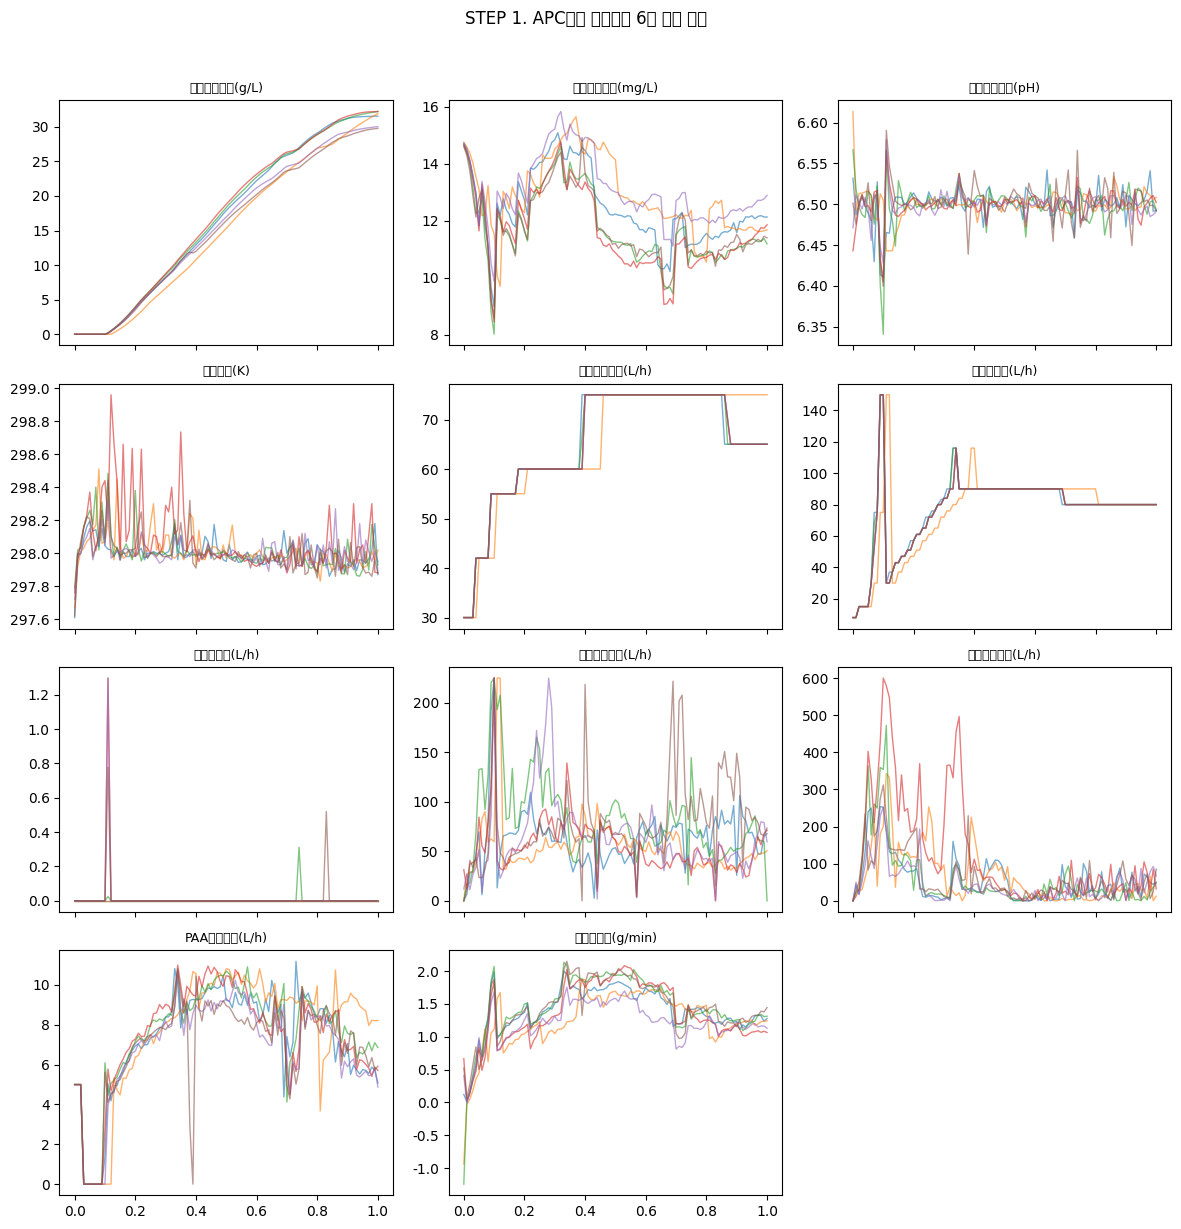

In [12]:
demo_strategy = fault_to_strategy[91]  # 'APC' — 이후 STEP3~5, 기여도 분석까지 배치91(Fault) 예시로 계속 사용

n_feat = len(feature_cols_final)
ncols = 3
nrows = int(np.ceil(n_feat / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharex=True)
axes = axes.flatten()
for i, feat in enumerate(feature_cols_final):
    ax = axes[i]
    for gb in golden_batches[demo_strategy]:
        subg = df[df['배치번호'] == gb].sort_values(time_col)
        prog_g = subg[time_col] / subg[time_col].max()
        vals_g = np.interp(common_points, prog_g, subg[feat])
        ax.plot(common_points, vals_g, alpha=0.6, lw=1)
    ax.set_title(feat, fontsize=9)
for j in range(n_feat, len(axes)):
    axes[j].axis('off')
fig.suptitle(f'STEP 1. {demo_strategy}전략 골든배치 {len(golden_batches[demo_strategy])}개 원본 궤적', y=1.02)
plt.tight_layout()
plt.show()

## STEP2. 골든밴드 생성

### 변수 11개 선정 근거
동일 데이터셋(IndPenSim)·동일 목적(골든배치 기반 편차 진단)의 선행 연구(Luo, He, Darko, 2024)가 사용한 CPP(Critical Process Parameter) 목록을 그대로 채택.

- 사람이 직접 조작하는 핵심 변수(당/공기/산/염기/PAA/냉난방수 공급유량)와, 그 결과로 나타나는 핵심 반응 지표(pH, 온도, DO2, 산소소모율, 페니실린농도)로 구성
- 발효조부피/중량, 배가스 비율 등은 다른 변수의 파생값이거나 직접 조작 대상이 아니라서 제외
- **PAA투입유량**: 포함 여부를 실제로 테스트한 결과 성능이 소폭 낮아지긴 했으나, 페니실린 생합성의 핵심 원료 공급 변수라는 논문 근거가 있어 최종 유지(11개 확정)
- **산투입유량**: 제외 시 성능 차이가 미미해 원안 그대로 유지

### 보간 방법 확정
- **연속형(자연 변동) 7개** — 페니실린농도, 용존산소농도, 수소이온농도, 발효온도, 염기투입유량, 냉난방수유량, 산소소모율: 생물학적으로 매끄럽게 변하므로 `PchipInterpolator`로 연속 보간
- **계단형(레시피 고정) 4개** — 공기주입유량, 당공급유량, 산투입유량, PAA투입유량: 사람이 미리 정해둔 스케줄대로 계단식으로 움직이므로, 중간을 매끄럽게 잇지 않고 **이전 측정값을 그대로 유지(forward-fill)**
  - (탐색 초반에는 계단형을 2개(공기주입유량, 당공급유량)로만 분류했었으나, 팀 논의 후 산투입유량·PAA투입유량도 레시피성 계단형이라는 데 합의하여 4개로 통일)

In [13]:
step_vars_final = ['공기주입유량(L/h)', '당공급유량(L/h)', '산투입유량(L/h)', 'PAA투입유량(L/h)']
continuous_vars_final = [f for f in feature_cols_final if f not in step_vars_final]
print("계단형(4개):", step_vars_final)
print("연속형(7개):", continuous_vars_final)

계단형(4개): ['공기주입유량(L/h)', '당공급유량(L/h)', '산투입유량(L/h)', 'PAA투입유량(L/h)']
연속형(7개): ['페니실린농도(g/L)', '용존산소농도(mg/L)', '수소이온농도(pH)', '발효온도(K)', '염기투입유량(L/h)', '냉난방수유량(L/h)', '산소소모율(g/min)']


In [14]:
from scipy.interpolate import PchipInterpolator


def interpolate_by_type(x_known, y_known, query_points, feat):
    # 연속형(feat)은 PCHIP 보간, 계단형(레시피)은 이전값 유지(forward-fill)
    if feat in step_vars_final:
        idx = np.searchsorted(x_known, query_points, side='right') - 1
        idx = np.clip(idx, 0, len(x_known) - 1)
        return y_known[idx]
    else:
        # approx_progress처럼 clip(upper=1.0)이 걸린 x는 끝부분에 중복값이 생겨
        # PchipInterpolator가 요구하는 "엄격한 증가" 조건을 깨뜨림 -> 중복 제거 후 보간
        x_unique, keep_idx = np.unique(x_known, return_index=True)
        y_unique = y_known[keep_idx]
        if len(x_unique) < 2:
            return np.full_like(query_points, y_unique[0] if len(y_unique) else np.nan, dtype=float)
        interpolator = PchipInterpolator(x_unique, y_unique, extrapolate=False)
        result = interpolator(query_points)
        result = np.where(query_points < x_unique[0], y_unique[0], result)
        result = np.where(query_points > x_unique[-1], y_unique[-1], result)
        return result


In [15]:
def build_golden_band(df, batch_list, feature_cols, time_col='공정진행률', n_points=101):
    # 골든배치들을 공정진행률(사후 확정된 진짜 진행률) 기준으로 정렬·보간해 지점별 평균/표준편차 밴드 생성
    pts = np.linspace(0, 1, n_points)
    result = {'공정진행률': pts}
    for feat in feature_cols:
        values = []
        for b in batch_list:
            sub = df[df['배치번호'] == b].sort_values(time_col)
            values.append(interpolate_by_type(sub[time_col].values, sub[feat].values, pts, feat))
        arr = np.array(values)
        result[feat + '_mean'] = arr.mean(axis=0)
        result[feat + '_std'] = arr.std(axis=0)
    return pd.DataFrame(result)

In [16]:
bands_meanstd = {
    s: build_golden_band(df, golden_batches[s], feature_cols_final, time_col='공정진행률')
    for s in ['RC', 'OC', 'APC']
}
bands_meanstd[demo_strategy].head()

,공정진행률,페니실린농도(g/L)_mean,페니실린농도(g/L)_std,용존산소농도(mg/L)_mean,용존산소농도(mg/L)_std,수소이온농도(pH)_mean,수소이온농도(pH)_std,발효온도(K)_mean,발효온도(K)_std,공기주입유량(L/h)_mean,...,산투입유량(L/h)_mean,산투입유량(L/h)_std,염기투입유량(L/h)_mean,염기투입유량(L/h)_std,냉난방수유량(L/h)_mean,냉난방수유량(L/h)_std,PAA투입유량(L/h)_mean,PAA투입유량(L/h)_std,산소소모율(g/min)_mean,산소소모율(g/min)_std
0,0.00,0.001000,0.000000e+00,14.688833,0.051972,6.521283,0.057373,297.695000,0.067515,30.0,...,0.0,0.0,7.239000,11.691967,0.000100,0.000000,5.0,0.0,-0.076092,0.739656
1,0.01,0.000995,4.262127e-07,14.449861,0.093723,6.492796,0.018122,297.974381,0.033186,30.0,...,0.0,0.0,16.573711,7.838591,31.596764,14.752412,5.0,0.0,0.013323,0.030743
2,0.02,0.000988,8.217911e-07,14.058258,0.189297,6.502055,0.005402,298.024333,0.025927,30.0,...,0.0,0.0,27.424146,10.178052,29.391951,11.389356,5.0,0.0,0.159983,0.066353
3,0.03,0.000982,1.263056e-06,13.453485,0.357156,6.504503,0.010524,298.109663,0.051074,30.0,...,0.0,0.0,31.666423,3.977168,78.848034,32.038246,0.0,0.0,0.371289,0.115986
4,0.04,0.000975,1.807578e-06,12.783823,0.472523,6.500312,0.009740,298.165120,0.061394,40.0,...,0.0,0.0,45.538270,11.017392,155.823317,63.564326,0.0,0.0,0.585110,0.157953


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


...

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


/sessions/elegant-sweet-cori/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44264 (\N{HANGUL SYLLABLE GOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/sessions/elegant-sweet-cori/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46304 (\N{HANGUL SYLLABLE DEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/sessions/elegant-sweet-cori/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/sessions/elegant-sweet-cori/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/sessions/elegant-sweet-cori/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWar

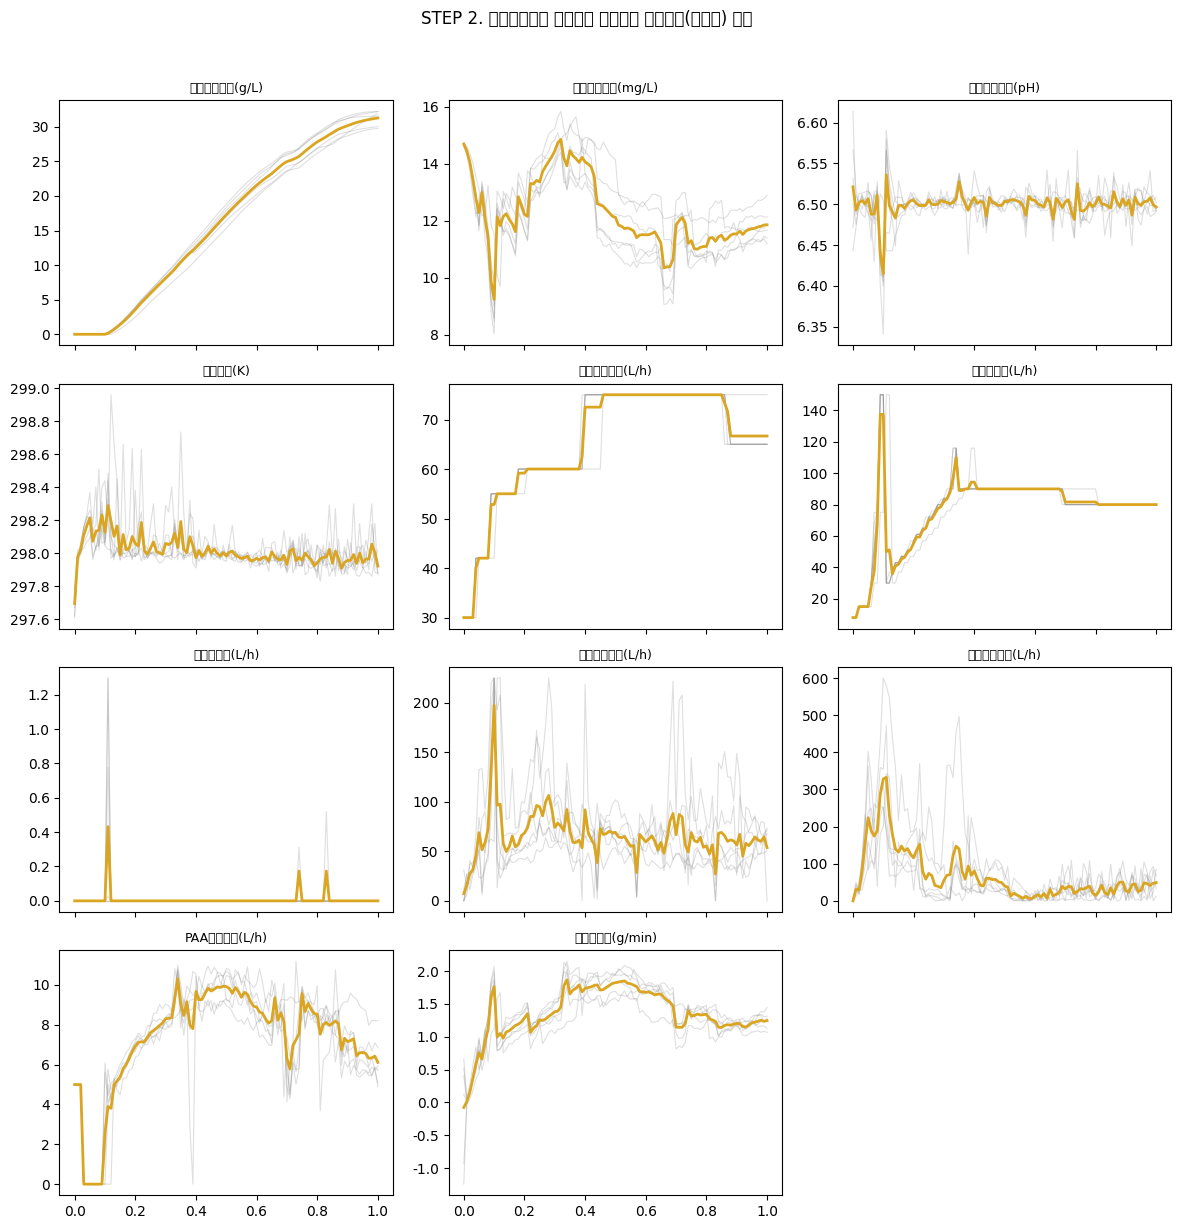

In [17]:
band_demo = bands_meanstd[demo_strategy]

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharex=True)
axes = axes.flatten()
for i, feat in enumerate(feature_cols_final):
    ax = axes[i]
    for gb in golden_batches[demo_strategy]:
        subg = df[df['배치번호'] == gb].sort_values(time_col)
        prog_g = subg[time_col] / subg[time_col].max()
        vals_g = np.interp(common_points, prog_g, subg[feat])
        ax.plot(common_points, vals_g, color='gray', alpha=0.25, lw=0.8)
    mean_line = band_demo[feat + '_mean'].values
    ax.plot(common_points, mean_line, color='goldenrod', lw=2)
    ax.set_title(feat, fontsize=9)
for j in range(n_feat, len(axes)):
    axes[j].axis('off')
fig.suptitle('STEP 2. 골든배치들을 지점별로 평균내어 골든밴드(기준선) 생성', y=1.02)
plt.tight_layout()
plt.show()


## STEP3. 이탈점수 계산

### SMAPE 기반 이탈점수
탐색 초반에는 Z-score, robust Z-score(median/MAD), MAPE, hybrid(Z 기반), abs_diff 등 6가지 공식을 비교했으나, 스케일이 다른 변수를 함께 평균 내도 안정적이고 0~1 범위로 해석이 쉬운 **SMAPE(대칭 평균절대백분율오차)** 단독 방식이 최종 채택됨. (median/MAD 등 나머지 방식은 폐기)

SMAPE 공식(변수 1개, 시점 1개 기준):

```
score = |실제값 - 골든밴드평균| / (|실제값| + |골든밴드평균|)
```

11개 변수의 SMAPE를 시점별로 평균 낸 값이 그 시점의 "이탈점수".

### 그룹평균근사 진행률
- **골든밴드를 만들 때**는 이미 끝난 배치를 쓰므로 사후에 확정된 진짜 공정진행률(발효시간 ÷ 그 배치의 실제 최종시간)을 그대로 사용
- **실시간으로 진행 중인 배치를 골든밴드와 비교할 때**는 배치가 끝나기 전이라 "진짜 최종시간"을 알 수 없음 → 전략별(RC/OC/APC) **Train 배치(골든15+Train정상56=71개) 평균 배치길이**로 나눈 **그룹평균근사 진행률**을 사용
- 시간정렬 방식 비교 실험 결과 그룹평균근사가 절대시간 방식보다 진행률 오차가 낮아 실시간 근사값으로 채택

In [18]:
# 전략별 평균 배치길이 (골든배치 + Train 정상배치, 총 71개 기준 — 데이터 누수 방지 위해 Test는 제외)
group_avg_duration = {}
for s in ['RC', 'OC', 'APC']:
    ref_batches = golden_batches[s] + train_normal_batches[s]
    durations = df[df['배치번호'].isin(ref_batches)].groupby('배치번호')[time_col].max()
    group_avg_duration[s] = durations.mean()
group_avg_duration

{'RC': np.float64(232.125),
 'OC': np.float64(226.7391304347826),
 'APC': np.float64(225.45833333333334)}

In [19]:
def calc_smape_curve_custom(batch_id, band, strategy, feature_cols, time_col=time_col):
    # 배치 하나의 SMAPE 이탈점수 곡선(공정진행률 101개 지점) 계산 — 그룹평균근사 진행률 사용
    sub = df[df['배치번호'] == batch_id].sort_values(time_col)
    approx_progress = (sub[time_col] / group_avg_duration[strategy]).clip(upper=1.0)
    scores = []
    for feat in feature_cols:
        actual = interpolate_by_type(approx_progress.values, sub[feat].values, common_points, feat)
        ref = band[feat + '_mean'].values
        denom = np.abs(actual) + np.abs(ref)
        with np.errstate(invalid='ignore', divide='ignore'):
            s = np.where(denom < 1e-6, np.nan, np.abs(actual - ref) / denom)
        scores.append(s)
    return np.nanmean(np.array(scores), axis=0)


def calc_smape_per_feature(batch_id, band, strategy, feature_cols=feature_cols_final, time_col=time_col):
    # 변수별 SMAPE 이탈점수(11개 평균 내기 전) — 기여도 분석에 사용
    sub = df[df['배치번호'] == batch_id].sort_values(time_col)
    approx_progress = (sub[time_col] / group_avg_duration[strategy]).clip(upper=1.0)
    scores = {}
    for feat in feature_cols:
        actual = interpolate_by_type(approx_progress.values, sub[feat].values, common_points, feat)
        ref = band[feat + '_mean'].values
        denom = np.abs(actual) + np.abs(ref)
        with np.errstate(invalid='ignore', divide='ignore'):
            s = np.where(denom < 1e-6, np.nan, np.abs(actual - ref) / denom)
        scores[feat] = s
    return scores

In [20]:
# 공통 설정 — 이후 STEP3~STEP5, 기여도 분석까지 배치91(Fault, APC전략)을 예시로 계속 사용
strategy = fault_to_strategy[91]
band = bands_meanstd[strategy]
sub91 = df[df['배치번호'] == 91].sort_values(time_col)
approx_progress_91 = (sub91[time_col] / group_avg_duration[strategy]).clip(upper=1.0)
true_fault_mask_91 = np.interp(common_points, approx_progress_91, sub91[fault_col].values) > 0.5

fault_idx_91 = np.where(true_fault_mask_91)[0]
fault_progress_91 = common_points[fault_idx_91[0]] if len(fault_idx_91) > 0 else None

n_feat = len(feature_cols_final)
ncols = 3
nrows = int(np.ceil(n_feat / ncols))

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


...

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


/sessions/elegant-sweet-cori/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/sessions/elegant-sweet-cori/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/sessions/elegant-sweet-cori/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/sessions/elegant-sweet-cori/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'NanumGothic' not found.


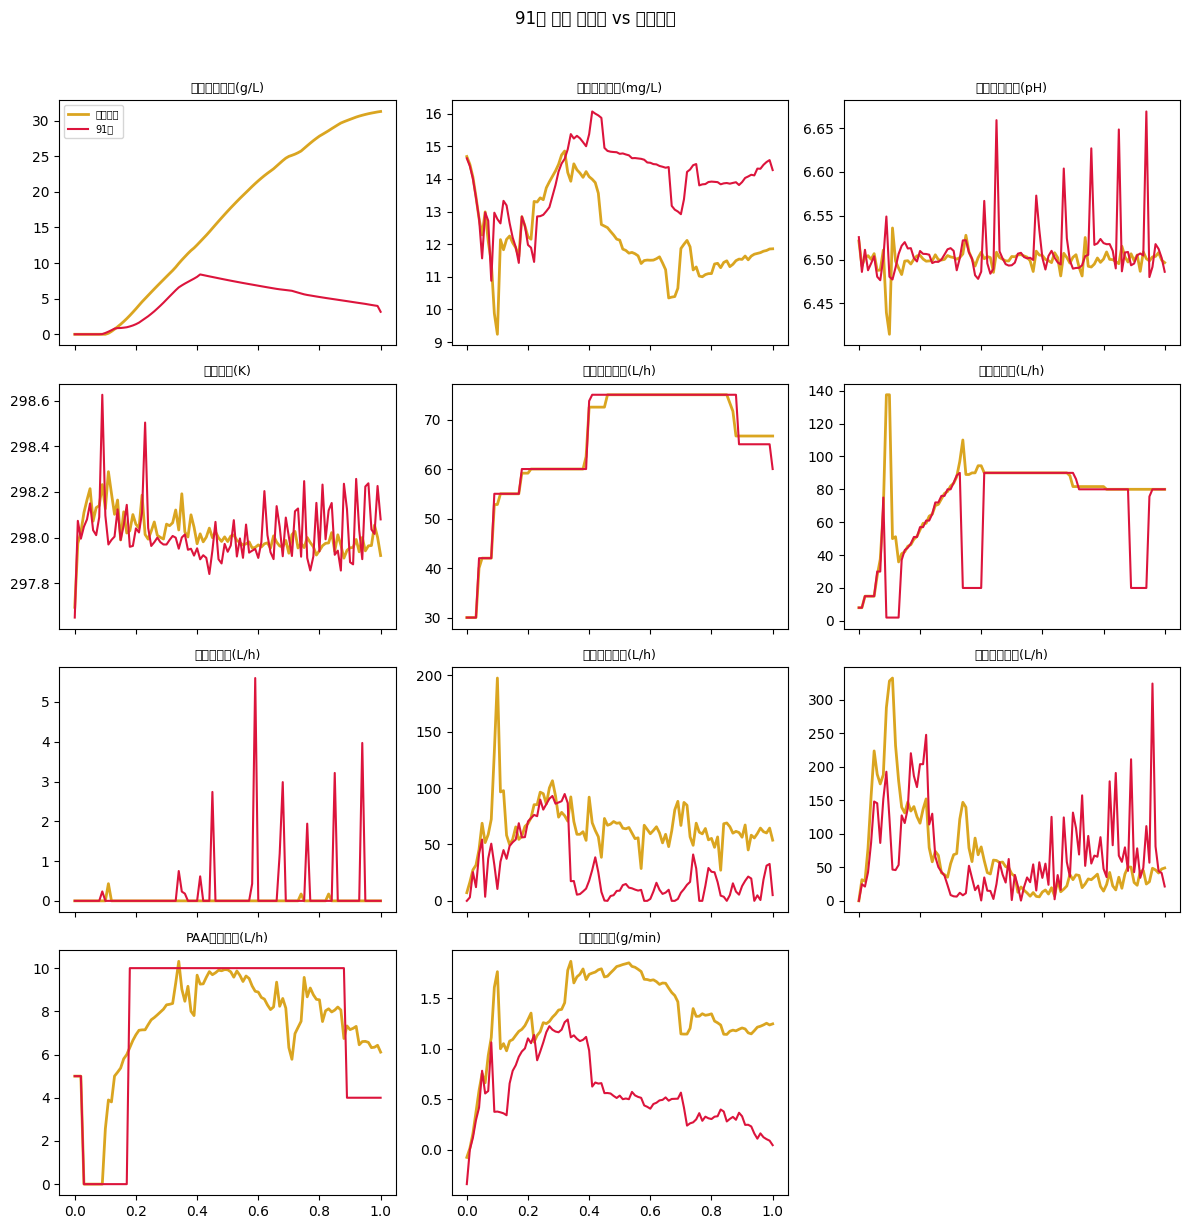

In [21]:
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharex=True)
axes = axes.flatten()
for i, feat in enumerate(feature_cols_final):
    ax = axes[i]
    mean_line = band[feat+'_mean'].values
    ax.plot(common_points, mean_line, color='goldenrod', lw=2, label='골든밴드')
    vals_91 = np.interp(common_points, approx_progress_91, sub91[feat])
    ax.plot(common_points, vals_91, color='crimson', lw=1.5, label='91번')
    ax.set_title(feat, fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)
for j in range(n_feat, len(axes)):
    axes[j].axis('off')
fig.suptitle('91번 배치 실제값 vs 골든밴드', y=1.02)
plt.tight_layout()
plt.show()

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


...

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


/sessions/elegant-sweet-cori/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/sessions/elegant-sweet-cori/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/sessions/elegant-sweet-cori/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53448 (\N{HANGUL SYLLABLE TAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/sessions/elegant-sweet-cori/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/sessions/elegant-sweet-cori/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: Us

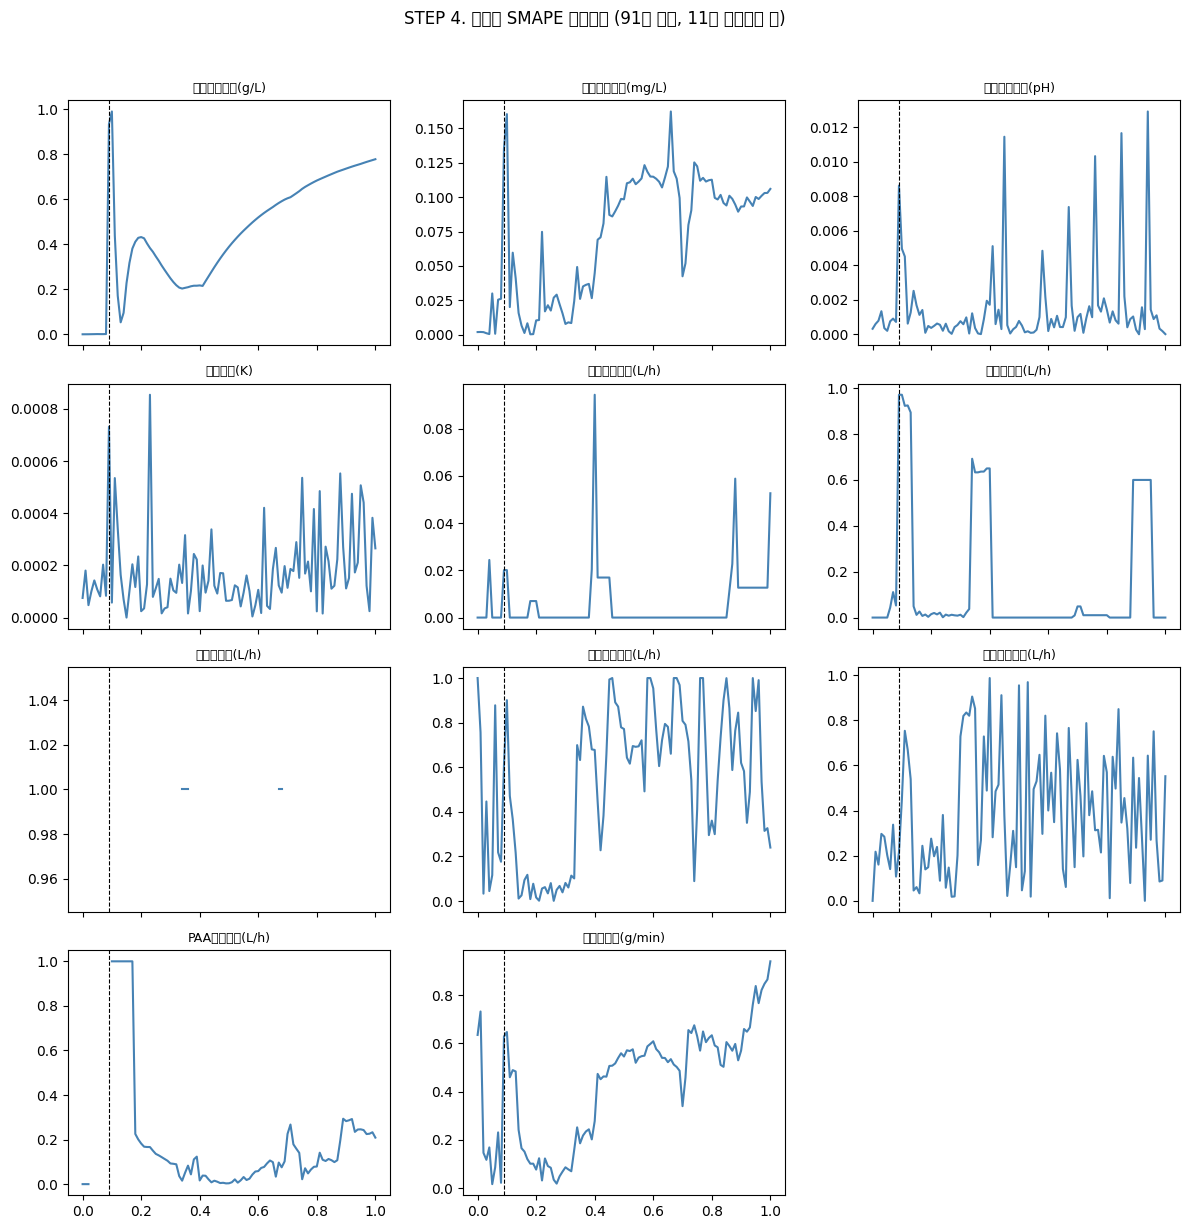

In [22]:
per_feat_scores_91 = calc_smape_per_feature(91, band, strategy)

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharex=True)
axes = axes.flatten()
for i, feat in enumerate(feature_cols_final):
    ax = axes[i]
    ax.plot(common_points, per_feat_scores_91[feat], color='steelblue', lw=1.5)
    if fault_progress_91 is not None:
        ax.axvline(fault_progress_91, color='black', ls='--', lw=0.8)
    ax.set_title(feat, fontsize=9)
for j in range(n_feat, len(axes)):
    axes[j].axis('off')
fig.suptitle('STEP 4. 변수별 SMAPE 이탈점수 (91번 배치, 11개 평균내기 전)', y=1.02)
plt.tight_layout()
plt.show()

## STEP4. 임계값 및 경보(3단계: 정상/주의/경고)

### 임계값: 전략별 평균 + 2.5σ (기존과 동일)
Train 정상배치(전략별)로 SMAPE 곡선을 지점별(공정진행률 0~100%, 101개 지점)로 모아 평균과 표준편차를 구하고, **평균 + 2.5×표준편차**를 그 지점의 임계값으로 사용. sigma_k를 1.5~7.0까지 스윕한 결과 2.5에서 재현율·정밀도·오탐률의 균형이 가장 좋아 확정된 값으로, 이번 3단계 설계에서도 그대로 재사용.

### 3단계 등급 판정: 지속조건(연속 지점 수)으로 주의/경고 구분
대시보드 요구사항에 따라 경보를 정상/주의/경고 3단계로 나눔. 이때 **새로운 시그마 임계값을 추가하지 않고**, 위에서 이미 검증된 2.5σ 임계값 하나만 유지한 채 "**얼마나 오래(연속 몇 지점) 넘었는지**"로 등급을 나눔:
- **주의**: 임계값을 넘었지만 1지점만 순간적으로 초과(연속 2지점 미만)
- **경고**: 임계값을 연속 2지점 이상 초과

낮은 시그마값으로 별도의 '주의' 임계값을 새로 만드는 방식은 배치단위오탐률이 68~100%까지 치솟아 폐기했고(사실상 상시경보), 지속조건 기준을 3지점 이상으로 올리는 대안도 에피소드탐지율이 52.4%까지 떨어져 폐기. **연속 2지점 이상 = 경고**가 배치단위오탐률과 에피소드탐지율의 트레이드오프가 가장 합리적이라 최종 확정(실제 고장 에피소드 중 1지점짜리는 없음을 길이 분포로 확인 후 결정).

### 정답 정의: 다중 pulse(fault_col) 직접 사용
한 배치 안에 fault_col이 0→1→0→1처럼 여러 번(다중 pulse) 짧게 나타남을 확인했으므로, "한 번 고장이 시작되면 끝까지 고장"이라는 단순 가정 대신 **fault_col을 그대로(포인트 단위) 정답으로 사용**.

### 최종 성능(대시보드 성능지표 = 경고단독 기준)
- **지점 단위**: 재현율(탐지율) 62.71%, FPR(오탐률) 10.00%, 정밀도 20.85%, 정확도 88.90%, F1 31.29
- **배치단위오탐률**: 21.05% (정상 holdout 배치 19개 중 경고가 1번이라도 뜬 배치 비율)
- **에피소드(pulse) 단위**: 21개 중 17개(81.0%) 탐지, 평균 탐지 지연 0.29%p

참고로 "주의+경고 전체"(=지속조건을 두지 않았던 기존 방식과 수학적으로 동일)는 재현율 67.80%·배치단위오탐률 47.37%·에피소드탐지율 95.2%(20/21)로 더 높지만, 배치단위오탐률이 너무 높아(정상 배치의 거의 절반에서 경보) 대시보드 성능지표로는 쓰지 않고, 경고단독 수치를 최종 성능으로 채택. 두 수치 비교는 아래 코드에서 함께 확인 가능.

In [23]:
def build_threshold(strategy, feature_cols=feature_cols_final, sigma_k=2.5):
    curves = np.array([
        calc_smape_curve_custom(b, bands_meanstd[strategy], strategy, feature_cols)
        for b in train_normal_batches[strategy]
    ])
    return np.nanmean(curves, axis=0) + sigma_k * np.nanstd(curves, axis=0)


SIGMA_K = 2.5
MIN_RUN = 2  # 연속 2지점 이상 초과부터 '경고' — 확정 이유는 위 마크다운 참고

thresholds = {s: build_threshold(s, feature_cols_final, sigma_k=SIGMA_K) for s in ['RC', 'OC', 'APC']}

In [24]:
def filter_min_run(flag, min_run=MIN_RUN):
    """연속 min_run지점 이상인 구간만 True로 남기고, 그보다 짧은 구간(순간 blip)은 False로 바꿈"""
    flag = np.asarray(flag)
    result = np.zeros_like(flag, dtype=bool)
    i, n = 0, len(flag)
    while i < n:
        if flag[i]:
            j = i
            while j < n and flag[j]:
                j += 1
            if j - i >= min_run:
                result[i:j] = True
            i = j
        else:
            i += 1
    return result


def get_raw_flag(batch_id, strategy, feature_cols=feature_cols_final, sigma_k=SIGMA_K):
    """임계값(평균+2.5σ)을 넘는 모든 지점 — 지속조건 적용 전(= '주의+경고 전체')"""
    curve = calc_smape_curve_custom(batch_id, bands_meanstd[strategy], strategy, feature_cols)
    return curve > thresholds[strategy]


def get_warning_flag(batch_id, strategy, feature_cols=feature_cols_final, min_run=MIN_RUN):
    """경고: 임계값을 연속 min_run지점 이상 초과하는 구간"""
    return filter_min_run(get_raw_flag(batch_id, strategy, feature_cols), min_run=min_run)


def get_caution_flag(batch_id, strategy, feature_cols=feature_cols_final, min_run=MIN_RUN):
    """주의: 임계값은 넘었지만 경고 조건(연속 min_run지점)에는 못 미치는 구간(1지점 blip)"""
    raw = get_raw_flag(batch_id, strategy, feature_cols)
    warning = filter_min_run(raw, min_run=min_run)
    return raw & ~warning


def get_alarm_flag(batch_id, strategy, feature_cols=feature_cols_final, sigma_k=SIGMA_K):
    """대시보드 성능지표 기준 경보 = 경고단독 (주의까지 포함하면 배치단위오탐률이 급증하므로 성능 판단은 경고로 함)"""
    return get_warning_flag(batch_id, strategy, feature_cols)


def get_fault_pulses(batch_id):
    # fault_col을 그룹평균근사 진행률에 맞춰 매핑한 뒤, 0→1→0 다중 pulse(에피소드) 구간을 전부 찾아냄
    strategy = fault_to_strategy[batch_id]
    sub = df[df['배치번호'] == batch_id].sort_values(time_col)
    approx_progress = (sub[time_col] / group_avg_duration[strategy]).clip(upper=1.0)
    true_mask = np.interp(common_points, approx_progress, sub[fault_col].values) > 0.5

    pulses = []
    in_pulse = False
    for i, v in enumerate(true_mask):
        if v and not in_pulse:
            start = i
            in_pulse = True
        if not v and in_pulse:
            pulses.append((start, i - 1))
            in_pulse = False
    if in_pulse:
        pulses.append((start, len(true_mask) - 1))
    return pulses

In [25]:
def metrics_from_counts(TP, FN, FP, TN):
    recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    fpr = FP / (FP + TN) if (FP + TN) > 0 else np.nan
    precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    f1 = 2 * precision * recall / (precision + recall) if (precision and recall) else np.nan
    return {'재현율(탐지율)': recall * 100, 'FPR(오탐률)': fpr * 100,
            '정밀도': precision * 100, '정확도': accuracy * 100, 'F1': f1 * 100}


def full_eval(flag_fn, label):
    """flag_fn(batch_id, strategy) -> bool array. 지점단위/배치단위오탐률/에피소드단위 성능을 한 번에 계산."""
    TP = FN = FP = TN = 0
    for b in fault_batches_all:
        strategy = fault_to_strategy[b]
        sub = df[df['배치번호'] == b].sort_values(time_col)
        approx_progress = (sub[time_col] / group_avg_duration[strategy]).clip(upper=1.0)
        true_mask = np.interp(common_points, approx_progress, sub[fault_col].values) > 0.5
        flag = flag_fn(b, strategy)
        TP += (flag & true_mask).sum(); FN += (~flag & true_mask).sum()
        FP += (flag & ~true_mask).sum(); TN += (~flag & ~true_mask).sum()
    for b in test_normal_19:
        strategy = df[df['배치번호'] == b]['제어전략그룹'].iloc[0]
        flag = flag_fn(b, strategy)
        FP += flag.sum(); TN += (~flag).sum()
    point_metrics = metrics_from_counts(TP, FN, FP, TN)

    batch_fp = sum(flag_fn(b, df[df['배치번호'] == b]['제어전략그룹'].iloc[0]).any() for b in test_normal_19)
    batch_fpr = batch_fp / len(test_normal_19) * 100

    hit = total = 0
    delays = []
    for b in fault_batches_all:
        strategy = fault_to_strategy[b]
        flag = flag_fn(b, strategy)
        for start, end in get_fault_pulses(b):
            total += 1
            if flag[start:end + 1].any():
                hit += 1
                first_alarm = start + np.where(flag[start:end + 1])[0][0]
                delays.append((common_points[first_alarm] - common_points[start]) * 100)

    return {
        '구분': label,
        **{k: round(v, 2) for k, v in point_metrics.items()},
        '배치단위오탐률(%)': round(batch_fpr, 2),
        '에피소드탐지율': f"{hit}/{total} ({hit/total:.1%})",
        '평균탐지지연(%p)': round(np.mean(delays), 2) if delays else np.nan,
    }

In [26]:
# 최종 성능 요약 — "전체"(주의+경고, 지속조건 없음)는 참고/비교용, "경고단독"이 대시보드 최종 성능지표
final_summary = pd.DataFrame([
    full_eval(get_raw_flag, '전체(주의+경고, 원래 지표)'),
    full_eval(get_warning_flag, '경고단독(최종 성능지표)'),
])
final_summary

,구분,재현율(탐지율),FPR(오탐률),정밀도,정확도,F1,배치단위오탐률(%),에피소드탐지율,평균탐지지연(%p)
0,"전체(주의+경고, 원래 지표)",67.80,11.42,19.95,87.74,30.83,47.37,20/21 (95.2%),1.05
1,경고단독(최종 성능지표),62.71,10.00,20.85,88.90,31.29,21.05,17/21 (81.0%),0.29


In [27]:
# "전체" 기준으로는 잡히지만 "경고단독" 기준으로는 완전히 놓치는(주의로만 남는) 에피소드 확인
for b in fault_batches_all:
    strategy = fault_to_strategy[b]
    raw = get_raw_flag(b, strategy)
    warning = get_warning_flag(b, strategy)
    for start, end in get_fault_pulses(b):
        hit_raw = raw[start:end + 1].any()
        hit_warning = warning[start:end + 1].any()
        if hit_raw and not hit_warning:
            print(f"배치{b} 에피소드({start}-{end}): 경고단독 기준으로는 완전히 놓침(주의로만 감지)")

배치92 에피소드(36-37): 경고단독 기준으로는 완전히 놓침(주의로만 감지)
배치92 에피소드(62-70): 경고단독 기준으로는 완전히 놓침(주의로만 감지)
배치98 에피소드(63-71): 경고단독 기준으로는 완전히 놓침(주의로만 감지)


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


...

/sessions/elegant-sweet-cori/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/sessions/elegant-sweet-cori/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49692 (\N{HANGUL SYLLABLE SUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


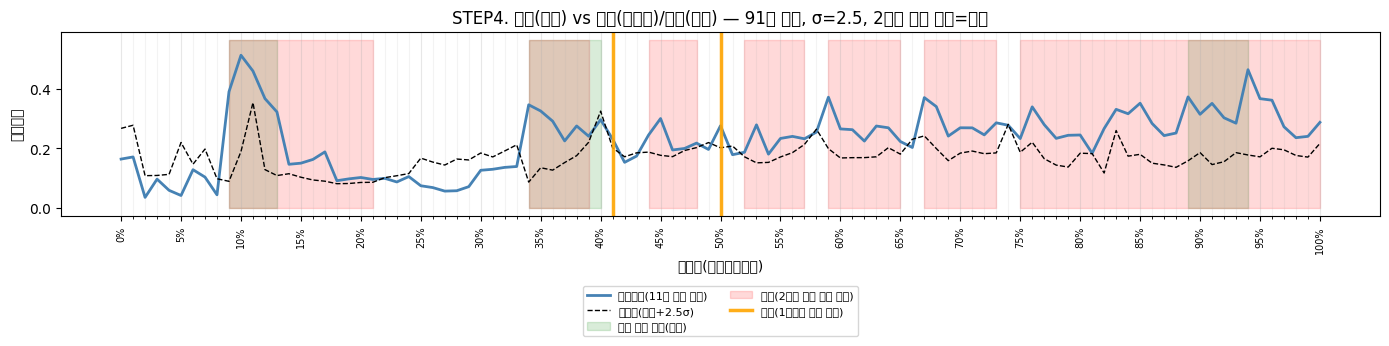

In [28]:
alarm_flag_경고_91 = get_warning_flag(91, strategy)
alarm_flag_주의_91 = get_caution_flag(91, strategy)
thresh_91 = thresholds[strategy]
curve_91 = calc_smape_curve_custom(91, band, strategy, feature_cols_final)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(common_points, curve_91, color='steelblue', lw=2, label='이탈점수(11개 변수 평균)')
ax.plot(common_points, thresh_91, color='black', ls='--', lw=1, label=f'임계값(평균+{SIGMA_K}σ)')
ax.fill_between(common_points, 0, curve_91.max()*1.1, where=true_fault_mask_91,
                 color='green', alpha=0.15, label='실제 고장 구간(정답)')
ax.fill_between(common_points, 0, curve_91.max()*1.1, where=alarm_flag_경고_91,
                 color='red', alpha=0.15, label=f'경고({MIN_RUN}지점 이상 연속 초과)')

# 주의는 폭이 없는 순간(1지점)이라 세로선으로 별도 표시
주의_x = common_points[alarm_flag_주의_91]
for i, x in enumerate(주의_x):
    ax.axvline(x, color='orange', lw=2.5, alpha=0.9,
               label='주의(1지점만 순간 초과)' if i == 0 else None)

ax.set_xticks(common_points, minor=True)
ax.set_xticks(common_points[::5])
ax.set_xticklabels([f'{x:.0%}' for x in common_points[::5]], rotation=90, fontsize=7)
ax.grid(which='minor', axis='x', alpha=0.15)
ax.grid(which='major', axis='x', alpha=0.3)

ax.set_title(f'STEP4. 정답(초록) vs 주의(주황선)/경고(빨강) — 91번 배치, σ={SIGMA_K}, {MIN_RUN}지점 이상 연속=경고')
ax.set_xlabel('진행률(그룹평균근사)')
ax.set_ylabel('이탈점수')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.35), ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## STEP5. 기여도 분석

### "최초 경보 시점" Top-3만 보기로 확정한 이유
처음에는 한 배치의 경보 구간 전체에서 어떤 변수가 1위 기여를 몇 번 했는지 누적 빈도를 집계하는 방식을 검토했으나, 이 방식은 **배치가 끝나야(경보 구간 전체를 알아야) 계산할 수 있어 실시간 운영에는 맞지 않음**. 실무에서 오퍼레이터에게 필요한 것은 "지금 막 경보가 뜬 시점에 어떤 변수가 문제인가"이므로, **최초 경보가 발생한 시점 하나의 Top-3 변수**만 보여주는 방식으로 최종 확정.

In [29]:
def get_top_contributors(batch_id, band, strategy, point_idx, top_n=3, feature_cols=feature_cols_final):
    per_feat = calc_smape_per_feature(batch_id, band, strategy, feature_cols)
    scores_at_point = {feat: per_feat[feat][point_idx] for feat in feature_cols}
    ranked = sorted(scores_at_point.items(), key=lambda x: x[1], reverse=True)
    return ranked[:top_n]

In [30]:
def diagnose_batch(batch_id, strategy=None, top_n=3):
    # 실시간 진단 파이프라인: 이탈점수 계산 -> 임계값 비교 -> 경보 여부 판정
    # -> (경보 시) 최초경보 시점 Top-N 기여 변수 반환
    if strategy is None:
        strategy = fault_to_strategy.get(batch_id) or df[df['배치번호'] == batch_id]['제어전략그룹'].iloc[0]
    band = bands_meanstd[strategy]
    curve = calc_smape_curve_custom(batch_id, band, strategy, feature_cols_final)
    alarm_flag = curve > thresholds[strategy]

    result = {
        '배치번호': batch_id,
        '전략': strategy,
        '경보발생': bool(alarm_flag.any()),
        '경보지점수': int(alarm_flag.sum()),
    }
    if alarm_flag.any():
        first_idx = np.where(alarm_flag)[0][0]
        result['최초경보_진행률'] = common_points[first_idx]
        result['기여도_Top3'] = get_top_contributors(batch_id, band, strategy, first_idx, top_n=top_n)
    return result

In [31]:
diagnose_batch(91)

{'배치번호': 91,
 '전략': 'APC',
 '경보발생': True,
 '경보지점수': 72,
 '최초경보_진행률': np.float64(0.09),
 '기여도_Top3': [('당공급유량(L/h)', np.float64(0.9713261648745519)),
  ('페니실린농도(g/L)', np.float64(0.9341371434988234)),
  ('용존산소농도(mg/L)', np.float64(0.13518740941118157))]}

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


...

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


91번 배치, 진행률 9% 시점 최초 경보
  당공급유량(L/h): 0.9713
  페니실린농도(g/L): 0.9341
  용존산소농도(mg/L): 0.1352


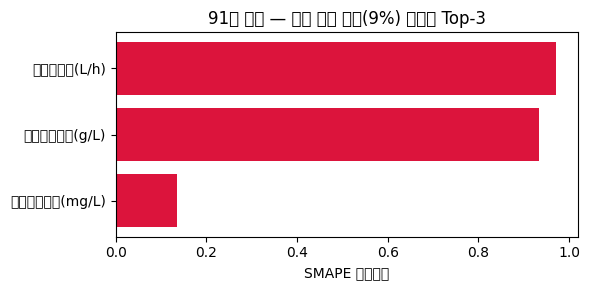

In [32]:
diag_91 = diagnose_batch(91)
alarm_flag_91 = get_alarm_flag(91, strategy)  # STEP4의 경고단독 기준(get_alarm_flag)과 동일한 정의 재사용
first_alarm_idx = np.where(alarm_flag_91)[0][0]
top3_first = diag_91['기여도_Top3']

print(f"91번 배치, 진행률 {common_points[first_alarm_idx]:.0%} 시점 최초 경보")
for feat, score in top3_first:
    print(f"  {feat}: {score:.4f}")

feats, scores = zip(*top3_first)
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(feats, scores, color='crimson')
ax.invert_yaxis()
ax.set_xlabel('SMAPE 이탈점수')
ax.set_title(f'91번 배치 — 최초 경보 시점({common_points[first_alarm_idx]:.0%}) 기여도 Top-3')
plt.tight_layout()
plt.show()

## ML 인계용 산출물 저장

주요업무: ML용 CV_score 계산에 필요한 관리한계 자료 전달 — 전략별 골든밴드의 지점별 평균·표준편차, 임계값 곡선을 정리해 전달.

아래 코드로 두 가지 산출물을 저장:
- `golden_profile.pkl`: 파이썬에서 그대로 불러 쓸 수 있는 전체 객체(pickle)
- `control_limits_for_ML.json`: ML팀이 다른 언어/툴에서도 바로 읽을 수 있는 사람이 읽기 쉬운 JSON

In [33]:
import pickle, json

golden_profile = {
    'common_points': common_points,          # 0~1, 101개 지점
    'feature_cols': feature_cols_final,       # 최종 11개 변수
    'golden_batches': golden_batches,         # 전략별 골든배치 번호
    'bands_meanstd': bands_meanstd,           # 전략별 {feat}_mean/{feat}_std DataFrame
    'group_avg_duration': group_avg_duration, # 전략별 평균 배치길이(그룹평균근사 진행률 계산용)
    'thresholds': thresholds,                 # 전략별 지점별 임계값 곡선(평균+2.5σ)
    'sigma_k': SIGMA_K,
    'min_run': MIN_RUN,                       # 2지점 이상 연속 초과 = 경고
}

with open('golden_profile.pkl', 'wb') as f:
    pickle.dump(golden_profile, f)

# ML팀 전달용 — 사람이 읽기 쉬운 JSON (전략별 지점별 평균/표준편차/임계값)
control_limits_for_ML = {}
for strategy_name in ['RC', 'OC', 'APC']:
    control_limits_for_ML[strategy_name] = {
        '공정진행률': common_points.tolist(),
        '임계값곡선': thresholds[strategy_name].tolist(),
        '변수별_평균표준편차': {
            feat: {
                'mean': bands_meanstd[strategy_name][feat + '_mean'].tolist(),
                'std': bands_meanstd[strategy_name][feat + '_std'].tolist(),
            } for feat in feature_cols_final
        }
    }

with open('control_limits_for_ML.json', 'w', encoding='utf-8') as f:
    json.dump(control_limits_for_ML, f, ensure_ascii=False, indent=2)

print('golden_profile.pkl / control_limits_for_ML.json 저장 완료')

golden_profile.pkl / control_limits_for_ML.json 저장 완료


## 한계 및 향후 과제

- **정밀도(19.51%)가 낮은 이유**: SMAPE 임계값을 넘는 지점 중 실제 고장이 아닌 경우(오탐, FPR 11.74%)가 재현율 대비 상대적으로 많음 — 정상 구간에서도 자연변동이 임계값 근처까지 흔들리는 지점이 존재하기 때문. 오탐 원인 변수별 세분화 분석은 향후 과제.
- **임계값 경계의 미세 미탐 사례**: 91번 배치의 진행률 약 40% 지점처럼, 이탈점수가 임계값에 근소하게 못 미쳐 정답(고장)인데 경보를 놓치는 경계 사례가 존재함.
- **레시피형(계단형) 변수의 타이밍 체크**: 산투입유량·당공급유량·공기주입유량·PAA투입유량은 "값이 정상범위를 벗어났는가"보다 "이벤트가 예상된 타이밍에 일어났는가"로 감시하는 게 더 적합하다는 방향성은 확인했으나, 실제 타이밍-어긋남 감지 로직 구현은 이번 범위에서 다루지 못해 향후 과제로 남김.

## GB_score ML 피처 산출

위에서 저장한 관리한계(control limit) 정보와는 별개로, ML팀이 GB_score(골든배치 기반 이탈도) 피처를 학습에 바로 쓸 수 있도록 배치별 대표값(50h/100h 컷오프 기준 평균·최대·기울기·초과비율)을 계산해 CSV로 저장합니다.

In [34]:
cols = feature_cols_final  # 11개(PAA 포함) 확정 변수셋

def interpolate_by_type(x_known, y_known, query_points, feat):
    if feat in step_vars_final:
        idx = np.searchsorted(x_known, query_points, side='right') - 1
        idx = np.clip(idx, 0, len(x_known) - 1)
        return y_known[idx]
    else:
        x_unique, keep_idx = np.unique(x_known, return_index=True)
        y_unique = y_known[keep_idx]
        if len(x_unique) < 2:
            return np.full_like(query_points, y_unique[0] if len(y_unique) else np.nan, dtype=float)
        interpolator = PchipInterpolator(x_unique, y_unique, extrapolate=False)
        result = interpolator(query_points)
        result = np.where(query_points < x_unique[0], y_unique[0], result)
        result = np.where(query_points > x_unique[-1], y_unique[-1], result)
        return result

def build_full_bands(cols):
    return {s: build_golden_band(df, golden_batches[s], cols, time_col='공정진행률') for s in ['RC', 'OC', 'APC']}

def build_loo_bands(cols):
    return {s: {b: build_golden_band(df, [x for x in batches if x != b], cols, time_col='공정진행률')
                for b in batches}
            for s, batches in golden_batches.items()}

def get_band(batch_id, strategy, cols, full_bands, loo_bands):
    if batch_id in golden_batches.get(strategy, []):
        return loo_bands[strategy][batch_id]
    return full_bands[strategy]

def build_threshold_for_cols(cols, full_bands, sigma_k=2.5):
    return {s: np.nanmean([calc_smape_curve_custom(b, full_bands[s], s, cols) for b in train_normal_batches[s]], axis=0)
               + sigma_k * np.nanstd([calc_smape_curve_custom(b, full_bands[s], s, cols) for b in train_normal_batches[s]], axis=0)
            for s in ['RC', 'OC', 'APC']}

full_bands = build_full_bands(cols)
loo_bands = build_loo_bands(cols)
thresh_dict = build_threshold_for_cols(cols, full_bands)

def compute_final_gb_features(batch_id):
    strategy = fault_to_strategy.get(batch_id) or df[df['배치번호'] == batch_id]['제어전략그룹'].iloc[0]
    band = get_band(batch_id, strategy, cols, full_bands, loo_bands)

    def curve_upto(cutoff_hour):
        sub = df[(df['배치번호'] == batch_id) & (df[time_col] <= cutoff_hour)].sort_values(time_col)
        if len(sub) < 2:
            return None, None, None
        approx_progress = (sub[time_col] / group_avg_duration[strategy]).clip(upper=1.0)
        cutoff_progress = min(cutoff_hour / group_avg_duration[strategy], 1.0)
        pts_mask = common_points <= cutoff_progress
        pts = common_points[pts_mask]
        times_at_pts = pts * group_avg_duration[strategy]

        scores = []
        for feat in cols:
            actual = interpolate_by_type(approx_progress.values, sub[feat].values, pts, feat)
            ref = band[feat + '_mean'].values[pts_mask]
            denom = np.abs(actual) + np.abs(ref)
            with np.errstate(invalid='ignore', divide='ignore'):
                scores.append(np.where(denom < 1e-6, np.nan, np.abs(actual - ref) / denom))
        curve = np.nanmean(np.array(scores), axis=0)
        thresh = thresh_dict[strategy][pts_mask]
        return curve, thresh, times_at_pts

    curve_50, thresh_50, times_50 = curve_upto(50)
    curve_100, thresh_100, times_100 = curve_upto(100)

    result = {'GB_exceed_ratio_cut_11var_100h': np.nan, 'GB_mean_cut_11var_50h': np.nan,
              'GB_slope_recent_11var_50h': np.nan, 'GB_max_cut_11var_50h': np.nan}

    if curve_100 is not None:
        result['GB_exceed_ratio_cut_11var_100h'] = float(np.nanmean(curve_100 > thresh_100))

    if curve_50 is not None:
        result['GB_mean_cut_11var_50h'] = np.nanmean(curve_50)
        result['GB_max_cut_11var_50h'] = np.nanmax(curve_50)
        window_mask = times_50 >= 30
        if window_mask.sum() >= 2:
            result['GB_slope_recent_11var_50h'] = np.polyfit(times_50[window_mask], curve_50[window_mask], 1)[0]

    return result

final_gb_table = pd.DataFrame({b: compute_final_gb_features(b) for b in range(1, 101)}).T
final_gb_table.head()

,GB_exceed_ratio_cut_11var_100h,GB_mean_cut_11var_50h,GB_slope_recent_11var_50h,GB_max_cut_11var_50h
1,0.000000,0.080919,0.001058,0.279261
2,0.045455,0.080362,-0.003417,0.206129
3,0.022727,0.079423,0.000659,0.176081
4,0.000000,0.074640,-0.000728,0.161574
5,0.000000,0.075663,-0.002335,0.181123


In [35]:
# 1단계: final_gb_table을 배치번호 컬럼 있는 형태로 변환
final_gb_table_export = final_gb_table.reset_index().rename(columns={'index': '배치번호'})

# 2단계: 그걸 CSV로 저장
final_gb_table_export.to_csv('gb_score_features.csv', index=False, encoding='utf-8-sig')